In [2]:
!pip -q install datasets

import json
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yaml
from datasets import load_dataset
from google.colab import drive
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torchvision import models
from tqdm.auto import tqdm

os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"

drive.mount("/content/drive")

PROJECT_DIR="/content/drive/MyDrive/ATML-PA1"
os.environ["HF_HOME"]=PROJECT_DIR+"/hf_cache"
for folder in ["task3/configs","task3/results/checkpoints","task3/results/figures"]:
    os.makedirs(PROJECT_DIR+"/"+folder,exist_ok=True)
os.chdir(PROJECT_DIR)

if torch.cuda.is_available():
    DEVICE=torch.device("cuda")
else:
    DEVICE=torch.device("cpu")

torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
torch.use_deterministic_algorithms(True,warn_only=True)

print(torch.__version__,DEVICE,os.getcwd())
if DEVICE.type=="cuda":
    print(torch.cuda.get_device_name(0))

Mounted at /content/drive
2.11.0+cpu cpu /content/drive/MyDrive/ATML-PA1


In [ ]:
%%writefile task3/configs/task3.yaml
seed: 6304
dataset: pacs
unseen_domain: sketch
source_domains: [photo, art_painting, cartoon]
val_fraction: 0.2
resize: 256
crop: 224
lambda_dg: 1.0
rho: 0.05
sharpness_radius: 0.05

Writing task3/configs/task3.yaml


In [ ]:
NEEDED=["shared/splits/pacs_sketch_seed6304.json",
        "task2/results/checkpoints/source_only.pt",
        "task2/results/task2_results.json"]
missing=[]
for path in NEEDED:
    if os.path.exists(path)==True:
        print(f"found  {path}  {os.path.getsize(path)} bytes")
    else:
        print(f"MISSING {path}")
        missing.append(path)
if len(missing)>0:
    raise RuntimeError(f"task 3 cannot start, missing {missing}")

found  shared/splits/pacs_sketch_seed6304.json  167952 bytes
found  task2/results/checkpoints/source_only.pt  44800139 bytes
found  task2/results/task2_results.json  148776 bytes


In [ ]:
CONFIG=yaml.safe_load(open("task3/configs/task3.yaml"))
SEED=CONFIG["seed"]
UNSEEN_DOMAIN=CONFIG["unseen_domain"]
SOURCE_DOMAINS=CONFIG["source_domains"]
RESIZE=CONFIG["resize"]
CROP=CONFIG["crop"]

#task 2 splits loaded instead of recomputing
PROTOCOL=json.load(open("shared/splits/pacs_sketch_seed6304.json"))
assert PROTOCOL["seed"]==SEED
assert PROTOCOL["source_domains"]==SOURCE_DOMAINS
assert PROTOCOL["target_domain"]==UNSEEN_DOMAIN
CLASSES=PROTOCOL["classes"]
SPLITS=PROTOCOL["splits"]

dataset=load_dataset("flwrlabs/pacs",split="train")
LABELS=np.array(dataset["label"])
DOMAIN_OF=np.array(dataset["domain"])
assert list(dataset.features["label"].names)==CLASSES

#proves the row order matches task 2
for position,label in PROTOCOL["labels"].items():
    assert LABELS[int(position)]==label

for domain in SOURCE_DOMAINS:
    print(f"{domain:<14}train {len(SPLITS[domain]['train']):>5}  val {len(SPLITS[domain]['val']):>5}")
print(f"{UNSEEN_DOMAIN:<14}held out entirely {len(SPLITS[UNSEEN_DOMAIN]['all'])}")

SKETCH_POSITIONS=set(SPLITS[UNSEEN_DOMAIN]["all"])


def refuse_target(positions):
    for position in positions:
        if int(position) in SKETCH_POSITIONS:
            raise RuntimeError("a sketch row reached a source-only code path")


IMAGE_BANK=torch.empty((len(dataset),3,RESIZE,RESIZE),dtype=torch.uint8)
for position in tqdm(range(len(dataset))):
    image=dataset[position]["image"].convert("RGB").resize((RESIZE,RESIZE),Image.BICUBIC)
    IMAGE_BANK[position]=torch.from_numpy(np.array(image)).permute(2,0,1)
print("image bank",tuple(IMAGE_BANK.shape),f"{IMAGE_BANK.numel()/1e9:.2f} GB")

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  191MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9991 [00:00<?, ? examples/s]

photo         train  1337  val   333
art_painting  train  1638  val   410
cartoon       train  1875  val   469
sketch        held out entirely 3929


  0%|          | 0/9991 [00:00<?, ?it/s]

image bank (9991, 3, 256, 256) 1.96 GB


In [ ]:
IMAGENET_MEAN=torch.tensor([0.485,0.456,0.406]).view(1,3,1,1).to(DEVICE)
IMAGENET_STD=torch.tensor([0.229,0.224,0.225]).view(1,3,1,1).to(DEVICE)
SOURCE_BATCH_PER_DOMAIN=8
EVAL_BATCH=64


def make_batch(positions,train,generator,allow_target=False):
    if allow_target==False:
        refuse_target(positions)
    batch=IMAGE_BANK[positions].to(DEVICE).float()/255.0
    if train==True:
        output=torch.empty((len(positions),3,CROP,CROP),device=DEVICE)
        for row in range(len(positions)):
            top=int(torch.randint(0,RESIZE-CROP+1,(1,),generator=generator).item())
            left=int(torch.randint(0,RESIZE-CROP+1,(1,),generator=generator).item())
            tile=batch[row:row+1,0:,top:top+CROP,left:left+CROP]
            if float(torch.rand(1,generator=generator).item())<0.5:
                tile=torch.flip(tile,dims=[3])
            output[row:row+1]=tile
        batch=output
    else:
        offset=(RESIZE-CROP)//2
        batch=batch[0:,0:,offset:offset+CROP,offset:offset+CROP]
    return (batch-IMAGENET_MEAN)/IMAGENET_STD


def make_sampler(pool,batch_size,seed):
    random_state=np.random.RandomState(seed)
    pool=np.array(pool)
    return {"pool":pool,"batch_size":batch_size,"random_state":random_state,
            "order":random_state.permutation(len(pool)),"cursor":0}


def next_batch(sampler):
    if sampler["cursor"]+sampler["batch_size"]>len(sampler["order"]):
        sampler["order"]=sampler["random_state"].permutation(len(sampler["pool"]))
        sampler["cursor"]=0
    chosen=sampler["order"][sampler["cursor"]:sampler["cursor"]+sampler["batch_size"]]
    sampler["cursor"]=sampler["cursor"]+sampler["batch_size"]
    return sampler["pool"][chosen]

In [ ]:
def build_model():
    model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc=nn.Linear(512,len(CLASSES))
    return model.to(DEVICE)


def features_and_logits(model,batch):
    hidden=model.conv1(batch)
    hidden=model.bn1(hidden)
    hidden=model.relu(hidden)
    hidden=model.maxpool(hidden)
    hidden=model.layer1(hidden)
    hidden=model.layer2(hidden)
    hidden=model.layer3(hidden)
    hidden=model.layer4(hidden)
    feature=hidden.mean(dim=(2,3))
    return feature,model.fc(feature)


def set_training_mode(model):
    #shared frozen batchnorm policy and iscalled before every forward pass including both sam passes
    model.train()
    for module in model.modules():
        if isinstance(module,nn.BatchNorm2d)==True:
            module.eval()


#manual says load the task 2 source-only checkpoint rather than retraining erm
ERM_MODEL=build_model()
ERM_MODEL.load_state_dict(torch.load("task2/results/checkpoints/source_only.pt",
                                     map_location=DEVICE,weights_only=True))
ERM_MODEL.eval()
print("loaded the task 2 source-only checkpoint as the task 3 erm baseline")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


loaded the task 2 source-only checkpoint as the task 3 erm baseline


In [ ]:
def multi_kernel_mmd(first_feature,second_feature):
    #identical to task 2
    combined=torch.cat([first_feature,second_feature],dim=0)
    squared=torch.cdist(combined,combined,p=2.0)**2
    upper=torch.triu_indices(len(combined),len(combined),offset=1)
    median=squared[upper[0],upper[1]].detach().median()
    kernel=torch.zeros_like(squared)
    for multiple in [0.5,1.0,2.0]:
        kernel=kernel+torch.exp(-squared/(multiple*median+1e-8))
    first_count=len(first_feature)
    second_count=len(second_feature)
    first_block=kernel[0:first_count,0:first_count]
    second_block=kernel[first_count:,first_count:]
    cross_block=kernel[0:first_count,first_count:]
    first_mean=(first_block.sum()-first_block.diag().sum())/(first_count*(first_count-1))
    second_mean=(second_block.sum()-second_block.diag().sum())/(second_count*(second_count-1))
    return first_mean+second_mean-2.0*cross_block.mean()


def pairwise_source_mmd(domain_features):
    #the three unordered pairs averaged
    total=torch.zeros((),device=DEVICE)
    pair_count=0
    for first in range(len(domain_features)):
        for second in range(first+1,len(domain_features)):
            total=total+multi_kernel_mmd(domain_features[first],domain_features[second])
            pair_count=pair_count+1
    return total/pair_count

In [ ]:
def sam_perturb(model,rho):
    gradient_norm=torch.zeros((),device=DEVICE)
    for parameter in model.parameters():
        if parameter.grad is not None:
            gradient_norm=gradient_norm+parameter.grad.detach().pow(2).sum()
    gradient_norm=gradient_norm.sqrt()
    saved={}
    with torch.no_grad():
        for name,parameter in model.named_parameters():
            if parameter.grad is not None:
                saved[name]=parameter.detach().clone()
                parameter.add_(rho*parameter.grad/(gradient_norm+1e-12))
    return saved


def sam_restore(model,saved):
    with torch.no_grad():
        for name,parameter in model.named_parameters():
            if name in saved:
                parameter.copy_(saved[name])

In [ ]:
MAX_EPOCHS=30
LEARNING_RATE=1e-4
WEIGHT_DECAY=1e-4
PATIENCE=5


def evaluate(model,positions,allow_target=False):
    model.eval()
    positions=np.array(positions)
    predictions=[]
    with torch.no_grad():
        for start in range(0,len(positions),EVAL_BATCH):
            chunk=positions[start:start+EVAL_BATCH]
            _,logits=features_and_logits(model,make_batch(chunk,False,None,allow_target))
            predictions.append(logits.argmax(1).cpu())
    predictions=torch.cat(predictions).numpy()
    truth=LABELS[positions]
    return float((predictions==truth).mean()),float(f1_score(truth,predictions,average="macro")),predictions


def source_validation_report(model):
    per_domain={}
    accuracies=[]
    macro_f1_values=[]
    for domain in SOURCE_DOMAINS:
        accuracy,macro_f1,_=evaluate(model,SPLITS[domain]["val"])
        per_domain[domain]={"accuracy":accuracy,"macro_f1":macro_f1}
        accuracies.append(accuracy)
        macro_f1_values.append(macro_f1)
    return {"per_domain":per_domain,
            "mean_accuracy":float(np.mean(accuracies)),
            "mean_macro_f1":float(np.mean(macro_f1_values)),
            "worst_accuracy":float(np.min(accuracies)),
            "worst_macro_f1":float(np.min(macro_f1_values))}


def train_method(method,lambda_dg=1.0,rho=0.05):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    generator=torch.Generator().manual_seed(SEED)

    model=build_model()
    optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    criterion=nn.CrossEntropyLoss()

    source_samplers=[]
    for offset,domain in enumerate(SOURCE_DOMAINS):
        source_samplers.append(make_sampler(SPLITS[domain]["train"],SOURCE_BATCH_PER_DOMAIN,SEED+offset))

    source_train_total=0
    for domain in SOURCE_DOMAINS:
        source_train_total=source_train_total+len(SPLITS[domain]["train"])
    updates_per_epoch=math.ceil(source_train_total/(SOURCE_BATCH_PER_DOMAIN*len(SOURCE_DOMAINS)))

    history=[]
    best_macro_f1=-1.0
    best_state=None
    epochs_without_improvement=0
    for epoch in range(MAX_EPOCHS):
        classification_sum=0.0
        alignment_sum=0.0
        perturbed_sum=0.0
        gradient_norm_sum=0.0
        for update in range(updates_per_epoch):
            set_training_mode(model)

            source_positions=[]
            for sampler in source_samplers:
                source_positions.extend(next_batch(sampler).tolist())
            source_positions=np.array(source_positions)
            #built once and reused so sam's two passes see identical pixels
            batch=make_batch(source_positions,True,generator)
            truth=torch.tensor(LABELS[source_positions],device=DEVICE)

            alignment_loss=torch.zeros((),device=DEVICE)
            if method=="sam":
                optimizer.zero_grad()
                _,logits=features_and_logits(model,batch)
                classification_loss=criterion(logits,truth)
                classification_loss.backward()
                saved=sam_perturb(model,rho)
                optimizer.zero_grad()
                set_training_mode(model)
                _,perturbed_logits=features_and_logits(model,batch)
                perturbed_loss=criterion(perturbed_logits,truth)
                perturbed_loss.backward()
                sam_restore(model,saved)
                gradient_norm=torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
                optimizer.step()
                perturbed_sum=perturbed_sum+float(perturbed_loss.detach())
            else:
                feature,logits=features_and_logits(model,batch)
                classification_loss=criterion(logits,truth)
                if method=="dan_dg":
                    #eight rows per domain in sampler order so it slices cleanly, and one forward
                    #pass equals three separate ones because the batchnorm statistics are frozen
                    domain_features=[]
                    for index in range(len(SOURCE_DOMAINS)):
                        start=index*SOURCE_BATCH_PER_DOMAIN
                        domain_features.append(feature[start:start+SOURCE_BATCH_PER_DOMAIN])
                    alignment_loss=lambda_dg*pairwise_source_mmd(domain_features)
                optimizer.zero_grad()
                (classification_loss+alignment_loss).backward()
                gradient_norm=torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
                optimizer.step()

            classification_sum=classification_sum+float(classification_loss.detach())
            alignment_sum=alignment_sum+float(alignment_loss.detach())
            gradient_norm_sum=gradient_norm_sum+float(gradient_norm)

        report=source_validation_report(model)
        history.append({"epoch":epoch+1,
                        "classification_loss":classification_sum/updates_per_epoch,
                        "alignment_loss":alignment_sum/updates_per_epoch,
                        "perturbed_loss":perturbed_sum/updates_per_epoch,
                        "gradient_norm":gradient_norm_sum/updates_per_epoch,
                        "mean_source_val_macro_f1":report["mean_macro_f1"],
                        "worst_source_val_macro_f1":report["worst_macro_f1"],
                        "per_domain":report["per_domain"]})
        print(f"{method} epoch {epoch+1:>2}  cls {classification_sum/updates_per_epoch:.4f}  "
              f"align {alignment_sum/updates_per_epoch:.4f}  "
              f"gnorm {gradient_norm_sum/updates_per_epoch:.3f}  "
              f"mean {report['mean_macro_f1']:.4f}  worst {report['worst_macro_f1']:.4f}")

        if report["mean_macro_f1"]>best_macro_f1:
            best_macro_f1=report["mean_macro_f1"]
            best_state={}
            for key,value in model.state_dict().items():
                best_state[key]=value.clone()
            epochs_without_improvement=0
        else:
            epochs_without_improvement=epochs_without_improvement+1
            if epochs_without_improvement>=PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model,history,best_macro_f1

In [ ]:
MODELS={"erm":ERM_MODEL}
HISTORIES={}

TASK2=json.load(open("task2/results/task2_results.json"))
HISTORIES["erm"]=TASK2["histories"]["source_only"]

for method in ["dan_dg","sam"]:
    MODELS[method],HISTORIES[method],best=train_method(method)
    torch.save(MODELS[method].state_dict(),f"task3/results/checkpoints/{method}.pt")
    print(f"{method} best mean source-val macro-F1 {best:.4f}, epochs run {len(HISTORIES[method])}")

dan_dg epoch  1  cls 0.5223  align 0.0724  gnorm 14.129  mean 0.8900  worst 0.8496
dan_dg epoch  2  cls 0.2651  align 0.0371  gnorm 11.378  mean 0.8858  worst 0.8655
dan_dg epoch  3  cls 0.2113  align 0.0383  gnorm 10.983  mean 0.9218  worst 0.8923
dan_dg epoch  4  cls 0.1714  align 0.0275  gnorm 9.744  mean 0.9284  worst 0.9069
dan_dg epoch  5  cls 0.1376  align 0.0217  gnorm 8.960  mean 0.9191  worst 0.8947
dan_dg epoch  6  cls 0.1281  align 0.0249  gnorm 9.649  mean 0.9003  worst 0.8663
dan_dg epoch  7  cls 0.1328  align 0.0117  gnorm 9.571  mean 0.9277  worst 0.8984
dan_dg epoch  8  cls 0.1188  align 0.0402  gnorm 9.608  mean 0.9184  worst 0.8891
dan_dg epoch  9  cls 0.1189  align 0.0072  gnorm 9.056  mean 0.9019  worst 0.8604
dan_dg best mean source-val macro-F1 0.9284, epochs run 9
sam epoch  1  cls 0.7490  align 0.0000  gnorm 9.915  mean 0.8970  worst 0.8491
sam epoch  2  cls 0.2706  align 0.0000  gnorm 7.347  mean 0.9231  worst 0.9171
sam epoch  3  cls 0.1863  align 0.0000  gno

In [ ]:
def source_domain_separability(model):
    counts=[]
    for domain in SOURCE_DOMAINS:
        counts.append(len(SPLITS[domain]["val"]))
    count=min(counts)
    random_state=np.random.RandomState(SEED)

    model.eval()
    collected=[]
    domain_labels=[]
    for index,domain in enumerate(SOURCE_DOMAINS):
        pool=np.array(SPLITS[domain]["val"])
        positions=random_state.permutation(pool)[0:count]
        chunks=[]
        with torch.no_grad():
            for start in range(0,len(positions),EVAL_BATCH):
                feature,_=features_and_logits(model,make_batch(positions[start:start+EVAL_BATCH],False,None))
                chunks.append(feature.cpu())
        collected.append(torch.cat(chunks).numpy())
        domain_labels.append(np.full(count,index))
    features=np.concatenate(collected)
    domain_labels=np.concatenate(domain_labels)

    train_x,test_x,train_y,test_y=train_test_split(features,domain_labels,test_size=0.3,
                                                   random_state=SEED,stratify=domain_labels)
    classifier=LogisticRegression(C=1.0,max_iter=10000)
    classifier.fit(train_x,train_y)
    return float(classifier.score(test_x,test_y))


def build_sharpness_positions():
    #32 validation images from each source drawn once for each batch
    random_state=np.random.RandomState(SEED)
    positions=[]
    for domain in SOURCE_DOMAINS:
        pool=np.array(SPLITS[domain]["val"])
        chosen=random_state.permutation(len(pool))[0:32]
        positions.extend(pool[chosen].tolist())
    return np.array(positions)


SHARPNESS_POSITIONS=build_sharpness_positions()
print("sharpness batch",len(SHARPNESS_POSITIONS),"images")


def sharpness_proxy(model):
    model.eval()
    model.zero_grad()
    criterion=nn.CrossEntropyLoss()
    batch=make_batch(SHARPNESS_POSITIONS,False,None)
    truth=torch.tensor(LABELS[SHARPNESS_POSITIONS],device=DEVICE)
    _,logits=features_and_logits(model,batch)
    base_loss=criterion(logits,truth)
    base_loss.backward()
    saved=sam_perturb(model,0.05)
    with torch.no_grad():
        _,perturbed_logits=features_and_logits(model,batch)
        perturbed_loss=criterion(perturbed_logits,truth)
    sam_restore(model,saved)
    model.zero_grad()
    return float(perturbed_loss)-float(base_loss)

sharpness batch 96 images


In [ ]:
SOURCE_RESULTS={}
for method in ["erm","dan_dg","sam"]:
    row=source_validation_report(MODELS[method])
    row["source_domain_separability"]=source_domain_separability(MODELS[method])
    row["sharpness_proxy"]=sharpness_proxy(MODELS[method])
    SOURCE_RESULTS[method]=row

header=f"{'method':<10}"
for domain in SOURCE_DOMAINS:
    header=header+f"{domain[0:8]:>10}"
header=header+f"{'mean acc':>10}{'worst acc':>11}{'mean F1':>9}{'worst F1':>10}{'sep':>7}{'sharp':>9}"
print(header)
for method in SOURCE_RESULTS:
    row=SOURCE_RESULTS[method]
    line=f"{method:<10}"
    for domain in SOURCE_DOMAINS:
        line=line+f"{row['per_domain'][domain]['accuracy']:>10.4f}"
    line=line+f"{row['mean_accuracy']:>10.4f}{row['worst_accuracy']:>11.4f}"
    line=line+f"{row['mean_macro_f1']:>9.4f}{row['worst_macro_f1']:>10.4f}"
    line=line+f"{row['source_domain_separability']:>7.3f}{row['sharpness_proxy']:>9.4f}"
    print(line)
print("\nchance source-domain separability is 0.333")

/tmp/ipykernel_834/1525675980.py:61: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(perturbed_loss)-float(base_loss)


method         photo  art_pain   cartoon  mean acc  worst acc  mean F1  worst F1    sep    sharp
erm           0.9700    0.9000    0.8891    0.9197     0.8891   0.9193    0.8959  0.893   0.4494
dan_dg        0.9459    0.9122    0.9403    0.9328     0.9122   0.9284    0.9069  0.670   0.3462
sam           0.9670    0.9341    0.9595    0.9535     0.9341   0.9508    0.9352  0.863   0.1809

chance source-domain separability is 0.333


In [ ]:
EXPECTATION=("with the unbiased estimator the mmd penalty no longer carries a finite-sample floor, "
             "so raising lambda_dg should now trade source accuracy against source-domain "
             "separability smoothly rather than collapsing. separability should fall as lambda_dg "
             "rises. source accuracy should hold at 0.1 and 1 and dip at 10. sketch accuracy is "
             "expected to improve modestly at 0.1 and 1 and fall at 10 as the penalty starts "
             "removing class-discriminative information, but without the constant-prediction "
             "collapse seen before the estimator was corrected. recorded before any sketch number "
             "is read")
print(EXPECTATION)

LAMBDA_VALUES=[0.1,1.0,10.0]
STUDY={}
STUDY[1.0]={"mean_source_accuracy":SOURCE_RESULTS["dan_dg"]["mean_accuracy"],
            "worst_source_accuracy":SOURCE_RESULTS["dan_dg"]["worst_accuracy"],
            "source_domain_separability":SOURCE_RESULTS["dan_dg"]["source_domain_separability"],
            "sharpness_proxy":SOURCE_RESULTS["dan_dg"]["sharpness_proxy"]}
STUDY_MODELS={1.0:MODELS["dan_dg"]}

for value in [0.1,10.0]:
    model,history,best=train_method("dan_dg",lambda_dg=value)
    report=source_validation_report(model)
    STUDY[value]={"mean_source_accuracy":report["mean_accuracy"],
                  "worst_source_accuracy":report["worst_accuracy"],
                  "source_domain_separability":source_domain_separability(model),
                  "sharpness_proxy":sharpness_proxy(model)}
    STUDY_MODELS[value]=model
    HISTORIES[f"dan_dg_lambda_{value}"]=history
    print(f"lambda_dg {value}: mean source {report['mean_accuracy']:.4f}  "
          f"separability {STUDY[value]['source_domain_separability']:.3f}")

with the unbiased estimator the mmd penalty no longer carries a finite-sample floor, so raising lambda_dg should now trade source accuracy against source-domain separability smoothly rather than collapsing. separability should fall as lambda_dg rises. source accuracy should hold at 0.1 and 1 and dip at 10. sketch accuracy is expected to improve modestly at 0.1 and 1 and fall at 10 as the penalty starts removing class-discriminative information, but without the constant-prediction collapse seen before the estimator was corrected. recorded before any sketch number is read
dan_dg epoch  1  cls 0.5339  align 0.0162  gnorm 13.077  mean 0.8859  worst 0.8369
dan_dg epoch  2  cls 0.2511  align 0.0076  gnorm 10.490  mean 0.9278  worst 0.9012
dan_dg epoch  3  cls 0.1901  align 0.0067  gnorm 9.498  mean 0.9088  worst 0.8902
dan_dg epoch  4  cls 0.1541  align 0.0050  gnorm 8.658  mean 0.9355  worst 0.9200
dan_dg epoch  5  cls 0.1115  align 0.0043  gnorm 8.204  mean 0.9459  worst 0.9357
dan_dg epoc

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


lambda_dg 10.0: mean source 0.4728  separability 0.560


In [ ]:
sketch_positions=np.array(SPLITS[UNSEEN_DOMAIN]["all"])
sketch_truth=LABELS[sketch_positions]

RESULTS={}
for method in ["erm","dan_dg","sam"]:
    row=dict(SOURCE_RESULTS[method])
    accuracy,macro_f1,predictions=evaluate(MODELS[method],sketch_positions,allow_target=True)
    row["sketch_accuracy"]=accuracy
    row["sketch_macro_f1"]=macro_f1
    row["sketch_predictions"]=predictions.tolist()
    RESULTS[method]=row

for value in LAMBDA_VALUES:
    accuracy,macro_f1,_=evaluate(STUDY_MODELS[value],sketch_positions,allow_target=True)
    STUDY[value]["sketch_accuracy"]=accuracy
    STUDY[value]["sketch_macro_f1"]=macro_f1

header=f"{'method':<10}{'mean acc':>10}{'worst acc':>11}{'sketch acc':>12}{'sketch F1':>11}{'change':>9}{'sep':>7}{'sharp':>9}"
print(header)
for method in RESULTS:
    row=RESULTS[method]
    change=row["sketch_accuracy"]-RESULTS["erm"]["sketch_accuracy"]
    print(f"{method:<10}{row['mean_accuracy']:>10.4f}{row['worst_accuracy']:>11.4f}"
          f"{row['sketch_accuracy']:>12.4f}{row['sketch_macro_f1']:>11.4f}{change:>+9.4f}"
          f"{row['source_domain_separability']:>7.3f}{row['sharpness_proxy']:>9.4f}")

print(f"\n{'lambda_dg':<11}{'mean source':>13}{'separability':>14}{'sketch acc':>12}")
for value in LAMBDA_VALUES:
    row=STUDY[value]
    print(f"{value:<11}{row['mean_source_accuracy']:>13.4f}"
          f"{row['source_domain_separability']:>14.3f}{row['sketch_accuracy']:>12.4f}")

method      mean acc  worst acc  sketch acc  sketch F1   change    sep    sharp
erm           0.9197     0.8891      0.5849     0.5796  +0.0000  0.893   0.4494
dan_dg        0.9328     0.9122      0.7182     0.7032  +0.1334  0.670   0.3462
sam           0.9535     0.9341      0.7488     0.7718  +0.1639  0.863   0.1809

lambda_dg    mean source  separability  sketch acc
0.1               0.9494         0.823      0.6948
1.0               0.9328         0.670      0.7182
10.0              0.4728         0.560      0.1932


In [ ]:
per_class={}
for method in RESULTS:
    predictions=np.array(RESULTS[method]["sketch_predictions"])
    per_class[method]={}
    for class_index in range(len(CLASSES)):
        mask=sketch_truth==class_index
        per_class[method][CLASSES[class_index]]=float((predictions[mask]==class_index).mean())

task2_per_class=TASK2["per_class_target_accuracy"]

header=f"{'class':<10}{'support':>8}{'erm':>8}{'dan_dg':>9}{'sam':>8}{'t2 dan':>9}{'dg - dan':>10}"
print(header)
for class_index in range(len(CLASSES)):
    class_name=CLASSES[class_index]
    support=int((sketch_truth==class_index).sum())
    difference=per_class["dan_dg"][class_name]-task2_per_class["dan"][class_name]
    print(f"{class_name:<10}{support:>8}{per_class['erm'][class_name]:>8.3f}"
          f"{per_class['dan_dg'][class_name]:>9.3f}{per_class['sam'][class_name]:>8.3f}"
          f"{task2_per_class['dan'][class_name]:>9.3f}{difference:>+10.3f}")

print(f"\ntask 2 target-aware DAN sketch accuracy {TASK2['results']['dan']['target_accuracy']:.4f}")
print(f"task 3 target-free DAN-DG sketch accuracy {RESULTS['dan_dg']['sketch_accuracy']:.4f}")
print(f"shared ERM baseline {RESULTS['erm']['sketch_accuracy']:.4f}")

for method in ["dan_dg","sam"]:
    worst_name=CLASSES[0]
    worst_change=2.0
    best_name=CLASSES[0]
    best_change=-2.0
    for class_name in CLASSES:
        change=per_class[method][class_name]-per_class["erm"][class_name]
        if change<worst_change:
            worst_change=change
            worst_name=class_name
        if change>best_change:
            best_change=change
            best_name=class_name
    print(f"\n{method}: worst {worst_name} {worst_change:+.3f}, best {best_name} {best_change:+.3f}")
    matrix=confusion_matrix(sketch_truth,np.array(RESULTS[method]["sketch_predictions"]),
                            labels=range(len(CLASSES)))
    for class_name in [worst_name,best_name]:
        class_index=CLASSES.index(class_name)
        row=matrix[class_index].copy()
        row[class_index]=0
        confused=int(row.argmax())
        if row[confused]==0:
            print(f"  {class_name} -> no errors")
        else:
            print(f"  {class_name} -> mostly confused with {CLASSES[confused]} ({row[confused]} of {int(matrix[class_index].sum())})")

class      support     erm   dan_dg     sam   t2 dan  dg - dan
dog            772   0.228    0.324   0.541    0.339    -0.016
elephant       740   0.989    0.897   0.919    0.727    +0.170
giraffe        753   0.548    0.742   0.587    0.636    +0.106
guitar         608   0.666    0.860   0.954    0.875    -0.015
horse          816   0.580    0.866   0.762    0.665    +0.201
house           80   0.500    0.800   0.887    1.000    -0.200
person         160   0.369    0.344   0.806    0.119    +0.225

task 2 target-aware DAN sketch accuracy 0.6243
task 3 target-free DAN-DG sketch accuracy 0.7182
shared ERM baseline 0.5849

dan_dg: worst elephant -0.092, best house +0.300
  elephant -> mostly confused with dog (37 of 740)
  house -> mostly confused with giraffe (10 of 80)

sam: worst elephant -0.070, best person +0.438
  elephant -> mostly confused with dog (39 of 740)
  person -> mostly confused with elephant (22 of 160)


In [ ]:
lambda_study={}
for key in STUDY:
    lambda_study[str(key)]=STUDY[key]

summary={"seed":SEED,"classes":CLASSES,"unseen_domain":UNSEEN_DOMAIN,"source_domains":SOURCE_DOMAINS,
         "hyperparameters":{"max_epochs":MAX_EPOCHS,"learning_rate":LEARNING_RATE,
                            "weight_decay":WEIGHT_DECAY,"patience":PATIENCE,
                            "source_batch_per_domain":SOURCE_BATCH_PER_DOMAIN,
                            "lambda_dg":1.0,"rho":0.05,"sharpness_radius":0.05,
                            "grad_clip_norm":1.0,"mmd_estimator":"unbiased"},
         "pre_registered_expectation":EXPECTATION,
         "results":RESULTS,"per_class_sketch_accuracy":per_class,
         "lambda_study":lambda_study,"histories":HISTORIES}
json.dump(summary,open("task3/results/task3_results.json","w"),indent=1)
print("wrote task3/results/task3_results.json")

wrote task3/results/task3_results.json


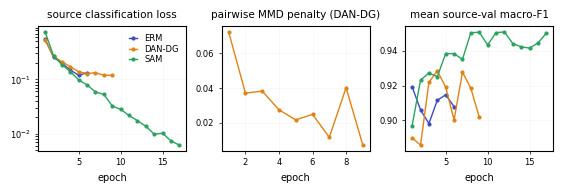

In [3]:
SAVED=json.load(open("task3/results/task3_results.json"))
CURVE_COLORS={"erm":"#3b4cc0","dan_dg":"#e08214","sam":"#2ca25f"}
CURVE_NAMES={"erm":"ERM","dan_dg":"DAN-DG","sam":"SAM"}

figure,axes=plt.subplots(1,3,figsize=(5.5,1.8))
for method in ["erm","dan_dg","sam"]:
    history=SAVED["histories"][method]
    epochs=[entry["epoch"] for entry in history]
    axes[0].plot(epochs,[entry["classification_loss"] for entry in history],marker="o",markersize=2,lw=1,
                 color=CURVE_COLORS[method],label=CURVE_NAMES[method])
    axes[2].plot(epochs,[entry["mean_source_val_macro_f1"] for entry in history],marker="o",markersize=2,lw=1,
                 color=CURVE_COLORS[method],label=CURVE_NAMES[method])
    if method=="dan_dg":
        axes[1].plot(epochs,[entry["alignment_loss"] for entry in history],marker="o",markersize=2,lw=1,
                     color=CURVE_COLORS[method],label=CURVE_NAMES[method])
axes[0].set_yscale("log")
axes[0].set_title("source classification loss",fontsize=7.5)
axes[1].set_title("pairwise MMD penalty (DAN-DG)",fontsize=7.5)
axes[2].set_title("mean source-val macro-F1",fontsize=7.5)
for axis in axes:
    axis.set_xlabel("epoch",fontsize=7)
    axis.tick_params(labelsize=6,length=2,width=0.5)
    axis.grid(alpha=0.15,lw=0.4)
axes[0].legend(frameon=False,fontsize=6,handlelength=1.0,labelspacing=0.2)
figure.tight_layout(pad=0.25,w_pad=0.7)
figure.savefig("task3/results/figures/training_curves.pdf",bbox_inches="tight")
plt.show()
